In [1]:
!pip install einx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 5.6 MB/s eta 0:00:00


In [2]:
!pip install jaxtyping

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.8 MB/s eta 0:00:00


In [3]:
def softmax(x, dim=-1):
    rescaled_input = x - torch.max(x, dim=dim, keepdim=True)[0]
    exponentiated_rescaled_input = torch.exp(rescaled_input)
    return exponentiated_rescaled_input / torch.sum(exponentiated_rescaled_input, dim=dim, keepdim=True)


def log_softmax(x, dim=-1):
    x_max = torch.max(x, dim=dim, keepdim=True)[0]
    x = x - x_max
    return x - torch.log(torch.sum(torch.exp(x), dim=dim, keepdim=True))


def cross_entropy(inputs, targets):
    negative_log_softmax_logits = -log_softmax(inputs)
    return torch.mean(torch.gather(negative_log_softmax_logits, -1, targets.unsqueeze(-1)))


def clip_gradient(parameters, max_norm):
    grads = [p.grad for p in parameters if p.grad is not None]
    norm = torch.tensor(0.0, device=grads[0].device)

    for g in grads:
        norm += (g**2).sum()

    norm = torch.sqrt(norm)
    clip_coef = min(1, max_norm / (norm + 1e-6))
    for g in grads:
        g *= clip_coef

In [4]:
from __future__ import annotations

import json
import logging
import math
import os
import warnings

import einx
import torch
import torch.nn as nn
import torch.utils.checkpoint # Import for gradient checkpointing
from einops import einsum, rearrange
from jaxtyping import Bool, Float, Int
from torch import Tensor

#from cs336_basics.nn_utils import softmax

logger = logging.getLogger(__name__)


class Linear(nn.Module):
    def __init__(self, d_in: int, d_out: int):
        """A linear layer initialized with truncated normal fan-in fan-out.

        Args:
            d_in: int
                The number of input features.
            d_out: int
                The number of output features.
        """

        super().__init__()
        std = math.sqrt(2 / (d_in + d_out))
        self.weight: Float[Tensor, " d_out d_in"] = nn.Parameter(
            nn.init.trunc_normal_(torch.empty(d_out, d_in), std=std, a=-3 * std, b=3 * std), requires_grad=True
        )

    def forward(self, x: Float[Tensor, " ... d_in"]) -> Float[Tensor, " ... d_out"]:
        return einsum(x, self.weight, "... d_in, d_out d_in -> ... d_out")

    def extra_repr(self):
        return f"d_out={self.weight.shape[0]}, d_in={self.weight.shape[1]}"


class Embedding(nn.Module):
    def __init__(self, vocab_size: int, d_model: int):
        super().__init__()
        std = 1.0
        self.weight = nn.Parameter(
            nn.init.trunc_normal_(torch.empty(vocab_size, d_model), std=std, a=-3 * std, b=3 * std), requires_grad=True
        )

    def forward(self, token_ids: Int[Tensor, " ..."]) -> Float[Tensor, " ... d_model"]:
        return self.weight[token_ids, :]

    def extra_repr(self):
        return f"vocab_size={self.weight.shape[0]}, d={self.weight.shape[1]}"


class RMSNorm(nn.Module):
    """
    This module implements root mean square layer normalization, as
    described in Eq. 4 of https://arxiv.org/abs/1910.07467

    Args:
        hidden_size: int
            Dimensionality of the input to normalize.
        eps: float, default is 1e-5
            A value added to the denominator for numerical stability.

    Returns:
        FloatTensor of same shape as input.
    """

    def __init__(
        self,
        hidden_size: int,
        eps: float = 1e-5,
        device=None,
    ):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(hidden_size, device=device))
        self.eps = eps

    def forward(self, x):
        """
        Args:
            x: FloatTensor of shape `(batch_size, *)`.
                The input to apply root mean square layer normalization on.

        Returns:
            FloatTensor of same shape as input
        """
        # NOTE: in practice, many implementations will
        # manually upcast the input to fp32 here to prevent overflow when you
        # square the input.
        # https://github.com/pytorch/pytorch/issues/66707
        in_dtype = x.dtype

        x = x.to(torch.float32)
        rms = torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
        x = x * rms

        return (self.weight * x).to(in_dtype)

    def extra_repr(self):
        return f"hidden_size={self.weight.shape[0]}, eps={self.eps}"


class RotaryEmbedding(nn.Module):
    def __init__(self, context_length: int, dim: int, theta: float = 10000.0):
        super().__init__()
        self.register_buffer(
            "_freq_cis_cache", RotaryEmbedding._init_cache(context_length, dim, theta), persistent=False
        )
        self._freq_cis_cache: Float[Tensor, "2 context_length half_dim"]

    @staticmethod
    def _init_cache(context_length: int, dim: int, theta: float) -> Float[Tensor, " 2 context_length half_dim"]:
        assert dim % 2 == 0

        d = torch.arange(0, dim, 2) / dim
        freqs = torch.tensor(theta) ** -d
        t = torch.arange(context_length)

        freqs = einsum(t, freqs, "t, f -> t f")

        cos, sin = torch.cos(freqs), torch.sin(freqs)
        return torch.stack((cos, sin))

    def forward(
        self, x: Float[Tensor, " ... seq d"], pos_ids: Int[Tensor, " ... seq"] | None
    ) -> Float[Tensor, " ... seq d"]:
        x1, x2 = rearrange(x, "... (half_d xy) -> xy ... half_d", xy=2).unbind(0)

        # Standard
        # cos, sin = self._freq_cis_cache[:, pos_ids, :]

        # einx
        if pos_ids is not None:
            cos, sin = einx.get_at("cos_sin [pos] half_dim, ... -> cos_sin ... half_dim", self._freq_cis_cache, pos_ids)
        else:
            seq_len = x.size(-2)
            cos, sin = self._freq_cis_cache[:, :seq_len, :].unbind(0)

        # 2D rotation matrix applied to pairs in x
        x1_rot = cos * x1 - sin * x2
        x2_rot = sin * x1 + cos * x2
        # result = einx.id("... x_half, ... x_half -> ... (x_half (1 + 1))", x1_rot, x2_rot).contiguous()
        result = torch.concat((x1_rot, x2_rot), dim=-1)
        return result

    def extra_repr(self):
        return f"context_length={self._freq_cis_cache.shape[0]}, dim/2={self._freq_cis_cache.shape[1]}"


class BasicsTransformerLM(nn.Module):
    """A Transformer language model.

    Args:
        vocab_size: int
            The number of unique items in the output vocabulary to be predicted.
        context_length: int,
            The maximum number of tokens to process at once.
        d_model: int
            The dimensionality of the model embeddings and sublayer outputs.
        num_layers: int
            The number of Transformer layers to use.
        num_heads: int
            Number of heads to use in multi-headed attention. `d_model` must be
            evenly divisible by `num_heads`.
        d_ff: int
            Dimensionality of the feed-forward inner layer (section 3.3).

    Returns:
        FloatTensor of shape (batch size, sequence_length, vocab_size) with the
        predicted unnormalized next-word distribution for each token.
    """

    def __init__(
        self,
        vocab_size: int,
        context_length: int,
        d_model: int,
        num_layers: int,
        num_heads: int,
        d_ff: int,
        rope_theta: float | None = 10_000.0,
        use_gradient_checkpointing: bool = False, # New parameter
    ):
        # Store the model configuration for serialization / deserialization
        self.config = {
            k: v for k, v in locals().items() if k != "self" and not (k.startswith("__") and k.endswith("__"))
        }
        super().__init__()
        self.context_length = context_length
        self.d_model = d_model
        self.token_embeddings = Embedding(vocab_size, d_model)
        d_head = d_model // num_heads
        self.positional_encoder = (
            RotaryEmbedding(context_length, d_head, rope_theta) if rope_theta is not None else None
        )

        self.layers = nn.ModuleList(
            [
                TransformerBlock(
                    d_model=d_model,
                    num_heads=num_heads,
                    d_ff=d_ff,
                    positional_encoder=self.positional_encoder,
                )
                for _ in range(num_layers)
            ]
        )
        self.ln_final = RMSNorm(d_model)
        self.lm_head = Linear(d_model, vocab_size)
        # Tie the weights, since the paper mentions that "we share the same weight
        # matrix between the two embedding layers and the pre-softmax linear transformation"
        # self.lm_head.weight = self.token_embeddings.weight
        # report number of parameters
        logger.info(f"number of non-embedding parameters: {self.get_num_params() / 1e6:.2f}M")
        self.use_gradient_checkpointing = use_gradient_checkpointing # Store the parameter

    def get_num_params(self) -> int:
        """
        Return the number of parameters in the model.
        For non-embedding count (default), the position embeddings get subtracted.
        The token embeddings would too, except due to the parameter sharing these
        params are actually used as weights in the final layer, so we include them.
        """
        n_params = sum(p.numel() for p in self.parameters())
        return n_params

    def forward(self, x: Int[Tensor, " ... sequence_length"]) -> Float[Tensor, " ... sequence_length vocab_size"]:
        """
        Args:
            x: Input IDs for language modeling.

        Returns: A FloatTensor of shape
            (batch size, sequence_length, vocab_size) with the predicted unnormalized next-word
            distribution for each token.
        """
        _, sequence_length = x.size()
        # (batch size, sequence_length, d_model)
        # NOTE: paper mentions "In the embedding layers, we multiply those
        # weights by sqrt(d_model)", but we aren't doing that here.
        embedded_tokens = self.token_embeddings(x)

        # (batch size, sequence_length, d_model)
        # x = self.positional_encoder(embedded_tokens, positions)
        x = embedded_tokens

        for layer in self.layers:
            # (batch size, sequence_length, d_model)
            if self.use_gradient_checkpointing:
                x = torch.utils.checkpoint.checkpoint(layer, x)
            else:
                x = layer(x)
        # (batch size, sequence_length, d_model)
        x = self.ln_final(x)
        # (batch size, sequence_length, vocab_size)
        logits = self.lm_head(x)
        return logits

    @torch.no_grad()
    def generate(
        self,
        x: torch.Tensor,
        max_new_tokens: int,
        temperature: float = 1.0,
        top_k: int | None = None,
        eos_token_id: int | None = None,
    ):
        """
        Args:
            x: LongTensor of shape `(1, sequence_length,)` or `(sequence_length, )`.
                Input IDs to condition on when generating.
            max_new_tokens: int
                Maximum number of tokens to generate.
            temperature: float
                Temperature to use during generation.
            top_k: int
                If provided, only sample from the `top_k` vocab items (by probability).
            eos_token_id: int
                If provided, stop generation when we generate this ID.

        Returns: A LongTensor of shape (max_new_tokens,) with the generated model output.
        """
        if x.dim() == 1:
            x = x.unsqueeze(0)
        original_sequence_length = x.size(-1)
        for _ in range(max_new_tokens):
            # Take the last `context_length` tokens if the input is
            # beyond the model's context length
            x = x[:, -self.context_length :] if x.size(1) > self.context_length else x
            # Get the logits from the model
            logits = self.forward(x)
            # Take the logits for the next token
            next_token_logits = logits[:, -1]
            # apply temperature scaling
            temperature_scaled_next_token_logits = next_token_logits / temperature
            # If top-k is provided, take the tokens with the highest score
            if top_k:
                topk_values, _ = torch.topk(
                    temperature_scaled_next_token_logits,
                    min(top_k, temperature_scaled_next_token_logits.size(-1)),
                )
                # Get the score of the kth item that we kept---items with lower scores should be masked.
                threshold = topk_values[:, -1]
                topk_mask = temperature_scaled_next_token_logits < threshold
                temperature_scaled_next_token_logits.masked_fill(topk_mask, float("-inf"))
            next_token_probabilities = softmax(temperature_scaled_next_token_logits, dim=-1)
            next_token_id = torch.multinomial(next_token_probabilities, 1)
            # End generation if we see the EOS token ID
            if eos_token_id is not None and next_token_id.item() == eos_token_id:
                break
            x = torch.cat((x, next_token_id), dim=-1)
        new_token_ids = x[:, original_sequence_length:]
        return new_token_ids

    @classmethod
    def from_pretrained(cls, pretrained_model_path: str):
        config_path = os.path.join(pretrained_model_path, "model_config.json")
        with open(config_path) as f:
            config = json.load(f)
        model = cls(**config)
        weights_path = os.path.join(pretrained_model_path, "model.pt")
        state_dict = torch.load(weights_path)

        # Remove _orig_mod. prefix that comes from serializing a compiled model
        unwanted_prefix = "_orig_mod."
        for k, _ in list(state_dict.items()):
            if k.startswith(unwanted_prefix):
                state_dict[k[len(unwanted_prefix) :]] = state_dict.pop(k)
        model.load_state_dict(state_dict)
        return model


class TransformerBlock(nn.Module):
    """A single Transformer layer.

    This implements a single layer of the Transformer, as described in section 3.1
    of the paper.

    Args:
        d_model: int
            The dimensionality of the model embeddings and sublayer outputs.
        num_heads: int
            Number of heads to use in multi-headed attention. `d_model` must be
            evenly divisible by `num_heads`.
        d_ff: int
            Dimensionality of the feed-forward inner layer (section 3.3).

    Returns:
        FloatTensor of shape `(batch_size, sequence_length, d_model)`.
    """

    def __init__(
        self,
        d_model: int,
        num_heads: int,
        d_ff: int,
        positional_encoder: RotaryEmbedding | None,
    ):
        super().__init__()
        self.attn = CausalMultiHeadSelfAttention(
            d_model=d_model,
            num_heads=num_heads,
            positional_encoder=positional_encoder,
        )
        self.ffn = SwiGLU(d_model=d_model, d_ff=d_ff)
        self.ln1 = RMSNorm(d_model)
        self.ln2 = RMSNorm(d_model)

    def forward(self, x: torch.Tensor):
        """
        Args:
            x: FloatTensor of shape `(batch_size, sequence_length, d_model)`.
                The input to process with the Transformer block.

        Returns:
            FloatTensor of shape `(batch_size, sequence_length, d_model)`.
        """
        # NOTE: this is a pre-norm Transformer, and differs from the original
        # description in the paper.
        # Apply the multi-head self-attention sublayer
        x_attn = self.attn(self.ln1(x))
        attn_sublayer_output = x + x_attn

        # Apply the feed-forward sublayer
        x_ffn = self.ffn(self.ln2(attn_sublayer_output))
        ffn_sublayer_output = attn_sublayer_output + x_ffn
        return ffn_sublayer_output


class SwiGLU(nn.Module):
    def __init__(self, d_model: int, d_ff: int):
        super().__init__()
        self.w1 = Linear(d_model, d_ff)
        self.w2 = Linear(d_ff, d_model)
        self.w3 = Linear(d_model, d_ff)

    def forward(self, x):
        return self.w2(silu(self.w1(x)) * self.w3(x))


def scaled_dot_product_attention(
    Q: Float[Tensor, " ... queries d_k"],
    K: Float[Tensor, " ... keys    d_k"],
    V: Float[Tensor, " ... keys    d_v"],
    mask: Bool[Tensor, " ... queries keys"] | None = None,
) -> Float[Tensor, " ... queries d_v"]:
    """Scaled dot-product attention.

    This function implements Eq. 1 of the Transformer paper.

    Args:
        Q: Tensor of queries, may have any number of leading dimensions.
        K: Tensor of keys, sharing leading dimensions with Q.
        V: Tensor of values, sharding leading dimensions with Q and K.
        mask: An (optional) mask of shape (..., seq_len, seq_len).
            Attention scores for positions with a mask value of `False` should
            be masked out, i.e., not affect the softmaxed attention probabilities.

    Returns:
        torch.FloatTensor of shape (..., seq_len, value_dimension)
        with the output of running your scaled dot product attention
        implementation with the provided key, query, and value tensors.
    """

    d_k = K.shape[-1]
    attention_scores = einsum(Q, K, "... query d_k, ... key d_k -> ... query key") / math.sqrt(d_k)

    if mask is not None:
        attention_scores = torch.where(mask, attention_scores, float("-inf"))

    attention_weights = softmax(attention_scores, dim=-1)  # Softmax over the key dimension

    return einsum(attention_weights, V, "... query key, ... key d_v ->  ... query d_v")


class CausalMultiHeadSelfAttention(nn.Module):
    """Multi-Head Self-Attention

    This function implements section 3.2.2 of the Transformer paper. In particular,
    given an input tensor of shape `(batch_size, sequence_length, d_model)`, we project
    it to create queries, keys, and values, and then perform causal multi-headed attention with
    those queries, keys, and values.

    Args:
        d_model: int
            The dimensionality of the model embeddings and sublayer outputs.
        num_heads: int
            Number of heads to use in multi-headed attention. `d_model` must be
            evenly divisible by `num_heads`.

    Returns:
        Tensor of shape `(batch_size, sequence_length, d_model)`.
    """

    def __init__(
        self,
        d_model: int,
        num_heads: int,
        positional_encoder: RotaryEmbedding | None = None,
    ):
        super().__init__()
        if positional_encoder is None:
            warnings.warn("No positional encoder provided", stacklevel=2)
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads

        self.d_k = d_model // num_heads
        self.d_v = self.d_k

        self.q_proj = Linear(self.d_model, self.num_heads * self.d_k)
        self.k_proj = Linear(self.d_model, self.num_heads * self.d_k)
        self.v_proj = Linear(self.d_model, self.num_heads * self.d_v)

        self.output_proj = Linear(self.num_heads * self.d_v, self.d_model)

        self.positional_encoder: RotaryEmbedding | None = positional_encoder  # RoPE

    def forward(
        self, x: Float[Tensor, " ... seq d_k"], token_positions: Int[Tensor, " ... seq"] | None = None
    ) -> Float[Tensor, " ... seq d_v"]:
        """
        Args:
            x: The input to perform multi-headed self-attention on.
            positional_ids: The positional indices along the sequence dimension of the input embeddings.

        Returns:
            Self-attention outputs.
        """
        *batch_dims, sequence_length, d_model = x.size()
        assert d_model == self.d_model

        Q = self.q_proj(x)
        K = self.k_proj(x)
        V = self.v_proj(x)

        # Take apart each head from the embedding dimension of Q, K, V to shape (..., num_heads, seq_len, d_k).
        Q, K, V = (
            rearrange(X, "... seq (heads d) -> ... heads seq d", heads=self.num_heads)
            for X in (Q, K, V)
        )  # fmt: skip

        if self.positional_encoder is not None:  # RoPE is enabled
            if token_positions is not None:  # We got explicit position ids
                # Duplicate token positions for each head
                token_positions = rearrange(token_positions, "... seq -> ... 1 seq")

            Q = self.positional_encoder(Q, token_positions)
            K = self.positional_encoder(K, token_positions)

        # Construct causal mask
        iota = torch.arange(sequence_length, device=x.device)
        qi = rearrange(iota, "query -> query 1")
        kj = rearrange(iota, "key   -> 1   key")
        causal_mask = qi >= kj  # (query, key)
        causal_mask = causal_mask.__getitem__((None,) * len(batch_dims) + (...,))  # Add appropriate leading dimensions

        # Shape: (..., num_heads, sequence_length, d_k)
        attn_output = scaled_dot_product_attention(K=K, Q=Q, V=V, mask=causal_mask)

        # Concatenate the attention output from all heads.
        # (..., sequence_length, num_heads * d_v).
        attn_output = rearrange(attn_output, "batch heads seq d_v -> batch seq (heads d_v)").contiguous()

        # Apply the output projection
        output = self.output_proj(attn_output)
        return output


def silu(x: torch.Tensor):
    return x * torch.sigmoid(x)


In [5]:
from __future__ import annotations

import math
from collections.abc import Callable, Iterable

import torch


def get_cosine_lr(
    it: int,
    max_learning_rate: float,
    min_learning_rate: float,
    warmup_iters: int,
    cosine_cycle_iters: int,
):
    """Cosine with warmup learning rate scheduler."""
    # First, we linearly warmup for warmup_iters steps.
    if it < warmup_iters:
        return max_learning_rate * it / warmup_iters
    # Then, if it > cosine_cycle_iters, we return min learning rate.
    if it > cosine_cycle_iters:
        return min_learning_rate
    # Else, we use cosine decay down to min learning rate.
    decay_ratio = (it - warmup_iters) / (cosine_cycle_iters - warmup_iters)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_learning_rate + coeff * (max_learning_rate - min_learning_rate)


class AdamW(torch.optim.Optimizer):
    def __init__(
        self,
        params: Iterable[torch.nn.parameter.Parameter],
        lr: float = 1e-3,
        betas: tuple[float, float] = (0.9, 0.999),
        eps: float = 1e-8,
        weight_decay: float = 0.01,
    ):
        if not 0.0 <= lr:
            raise ValueError(f"Invalid learning rate: {lr}")
        if not 0.0 <= eps:
            raise ValueError(f"Invalid epsilon value: {eps}")
        if not 0.0 <= betas[0] < 1.0:
            raise ValueError(f"Invalid beta parameter at index 0: {betas[0]}")
        if not 0.0 <= betas[1] < 1.0:
            raise ValueError(f"Invalid beta parameter at index 1: {betas[1]}")
        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay)
        super().__init__(params, defaults)

    def step(self, closure: Callable | None = None):
        loss = None
        if closure is not None:
            loss = closure()
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue

                grad = p.grad.data
                if grad.is_sparse:
                    raise RuntimeError("Adam does not support sparse gradients")

                state = self.state[p]
                alpha = group["lr"]
                beta_1, beta_2 = group["betas"]
                eps = group["eps"]
                t = state.get("t", 1)

                # Apply weight decay
                alpha_t = alpha * (math.sqrt(1 - (beta_2**t)) / (1 - (beta_1**t)))
                p.data -= alpha * group["weight_decay"] * p.data

                prev_m_t = state.get("m", torch.zeros_like(grad))
                prev_v_t = state.get("v", torch.zeros_like(grad))

                m_t = beta_1 * prev_m_t + ((1 - beta_1) * grad)
                v_t = beta_2 * prev_v_t + ((1 - beta_2) * torch.square(grad))

                # Apply adjusted gradient step
                p.data -= alpha_t * m_t / (torch.sqrt(v_t) + eps)

                state["m"] = m_t
                state["v"] = v_t
                state["t"] = t + 1
        return loss


In [6]:
from __future__ import annotations

import numpy as np
import numpy.typing as npt
import torch


def get_batch(
    dataset: npt.NDArray, batch_size: int, context_length: int, device: str
) -> tuple[torch.Tensor, torch.Tensor]:
    starting_idxs = torch.randint(len(dataset) - context_length, (batch_size,))
    x = torch.stack([
            torch.from_numpy((dataset[i : i + context_length]).astype(np.int64))
            for i in starting_idxs
    ])  # fmt: skip
    y = torch.stack(
        [
            torch.from_numpy((dataset[i + 1 : i + 1 + context_length]).astype(np.int64))
            for i in starting_idxs
        ]
    )  # fmt: skip
    if "cuda" in device:
        x = x.pin_memory().to(device, non_blocking=True)
        y = y.pin_memory().to(device, non_blocking=True)
    else:
        x = x.to(device)
        y = y.to(device)
    return x, y


In [7]:
import timeit
import torch
import torch.nn as nn
import numpy as np
from collections.abc import Callable

# Assuming BasicsTransformerLM, AdamW, cross_entropy, get_batch, and softmax are defined in previous cells
# from wUfbdh46n2e4 import BasicsTransformerLM
# from gxtcf7OC0tL9 import AdamW, get_cosine_lr
# from CYzqPCgI0e7I import cross_entropy, softmax
# from fu8zmb0o01y7 import get_batch

def benchmark_model(
    vocab_size: int = 10000,
    context_length: int = 128,
    d_model: int = 256,
    num_layers: int = 2,
    num_heads: int = 4,
    d_ff: int = 512,
    batch_size: int = 16,
    warmup_steps: int = 5,
    num_timing_steps: int = 10,
    benchmark_mode: str = "full_train", # "forward_only", "forward_backward", "full_train", "mixed_precision_train"
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
    use_mixed_precision: bool = False,
):
    """Performs end-to-end benchmarking of the model's forward, backward, and optimizer steps."""

    print(f"Benchmarking with device: {device}")
    print(f"Benchmark mode: {benchmark_mode}")
    print(f"Warmup steps: {warmup_steps}, Timing steps: {num_timing_steps}")
    if use_mixed_precision:
        print("Using Automatic Mixed Precision (AMP)")
        if device == "cpu":
            print("Warning: Mixed precision is typically for CUDA devices. Running on CPU may not show benefits.")

    # 1. Initialize a model
    model = BasicsTransformerLM(
        vocab_size=vocab_size,
        context_length=context_length,
        d_model=d_model,
        num_layers=num_layers,
        num_heads=num_heads,
        d_ff=d_ff,
    ).to(device)
    model.train()

    # 2. Generate a random batch of data
    # Create a dummy dataset for get_batch
    dummy_dataset = np.arange(vocab_size, dtype=np.int64)
    x, y = get_batch(dummy_dataset, batch_size, context_length, device)

    # Initialize optimizer and scaler for mixed precision
    optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
    scaler = None
    if use_mixed_precision and device == "cuda":
        scaler = torch.cuda.amp.GradScaler()

    # Define the step function based on the benchmark_mode and mixed precision setting
    def run_step():
        nonlocal optimizer, scaler
        if benchmark_mode == "forward_only":
            with torch.no_grad():
                with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_mixed_precision):
                    outputs = model(x)
                    loss = cross_entropy(outputs.view(-1, outputs.size(-1)), y.view(-1))
        elif benchmark_mode == "forward_backward":
            optimizer.zero_grad()
            with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_mixed_precision):
                outputs = model(x)
                loss = cross_entropy(outputs.view(-1, outputs.size(-1)), y.view(-1))

            if use_mixed_precision and scaler is not None:
                scaler.scale(loss).backward()
            else:
                loss.backward()
            model.zero_grad() # Clear gradients after backward pass
        elif benchmark_mode in ["full_train", "mixed_precision_train"]:
            optimizer.zero_grad()
            with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_mixed_precision):
                outputs = model(x)
                loss = cross_entropy(outputs.view(-1, outputs.size(-1)), y.view(-1))

            if use_mixed_precision and scaler is not None:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()
        else:
            raise ValueError(f"Unknown benchmark_mode: {benchmark_mode}")

        if device == "cuda":
            torch.cuda.synchronize()

    # 3. Run warm-up steps
    print("Running warm-up steps...")
    for _ in range(warmup_steps):
        run_step()
    print("Warm-up complete.")

    # 4. Time the execution of n steps
    print(f"Timing {num_timing_steps} steps...")
    start_time = timeit.default_timer()
    for _ in range(num_timing_steps):
        run_step()
    end_time = timeit.default_timer()
    print("Timing complete.")

    avg_time_per_step = (end_time - start_time) / num_timing_steps
    print(f"Average time per step ({benchmark_mode}, MP={use_mixed_precision}): {avg_time_per_step:.4f} seconds")
    return avg_time_per_step

# Example usage:
if __name__ == "__main__":
    print("Starting benchmarking...")

    # Benchmark forward_only
    time_forward = benchmark_model(benchmark_mode="forward_only", num_timing_steps=50)
    print("----------------------------------------")

    # Benchmark forward_backward
    time_forward_backward = benchmark_model(benchmark_mode="forward_backward", num_timing_steps=50)
    print("----------------------------------------")

    # Benchmark full_train (no mixed precision)
    time_full_train = benchmark_model(benchmark_mode="full_train", num_timing_steps=50, use_mixed_precision=False)
    print("----------------------------------------")

    # Benchmark full_train with mixed precision
    if torch.cuda.is_available():
        time_mixed_precision_train = benchmark_model(benchmark_mode="mixed_precision_train", num_timing_steps=50, use_mixed_precision=True)
        print("----------------------------------------")
    else:
        print("CUDA not available, skipping mixed precision benchmark.")
        time_mixed_precision_train = None

    print("Benchmarking complete!")


Starting benchmarking...
Benchmarking with device: cuda
Benchmark mode: forward_only
Warmup steps: 5, Timing steps: 50
Running warm-up steps...
Warm-up complete.
Timing 50 steps...
Timing complete.
Average time per step (forward_only, MP=False): 0.0216 seconds
----------------------------------------
Benchmarking with device: cuda
Benchmark mode: forward_backward
Warmup steps: 5, Timing steps: 50
Running warm-up steps...
Warm-up complete.
Timing 50 steps...
Timing complete.
Average time per step (forward_backward, MP=False): 0.0279 seconds
----------------------------------------
Benchmarking with device: cuda
Benchmark mode: full_train
Warmup steps: 5, Timing steps: 50
Running warm-up steps...
Warm-up complete.
Timing 50 steps...
Timing complete.
Average time per step (full_train, MP=False): 0.0301 seconds
----------------------------------------
Benchmarking with device: cuda
Benchmark mode: mixed_precision_train
Warmup steps: 5, Timing steps: 50
Using Automatic Mixed Precision (AMP)

/tmp/ipykernel_2200/3373999874.py:57: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Warm-up complete.
Timing 50 steps...
Timing complete.
Average time per step (mixed_precision_train, MP=True): 0.0246 seconds
----------------------------------------
Benchmarking complete!


In [8]:
import timeit
import torch
import torch.nn as nn
import numpy as np
from collections.abc import Callable

# Assuming BasicsTransformerLM, AdamW, cross_entropy, get_batch, and softmax are defined in previous cells
# from wUfbdh46n2e4 import BasicsTransformerLM
# from gxtcf7OC0tL9 import AdamW, get_cosine_lr
# from CYzqPCgI0e7I import cross_entropy, softmax
# from fu8zmb0o01y7 import get_batch

def benchmark_model(
    vocab_size: int = 10000,
    context_length: int = 128,
    d_model: int = 256,
    num_layers: int = 2,
    num_heads: int = 4,
    d_ff: int = 512,
    batch_size: int = 16,
    warmup_steps: int = 5,
    num_timing_steps: int = 10,
    benchmark_mode: str = "full_train", # "forward_only", "forward_backward", "full_train", "mixed_precision_train"
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
    use_mixed_precision: bool = False,
    profile_memory: bool = False, # New argument for memory profiling
):
    """Performs end-to-end benchmarking of the model's forward, backward, and optimizer steps."""

    print(f"Benchmarking with device: {device}")
    print(f"Benchmark mode: {benchmark_mode}")
    print(f"Warmup steps: {warmup_steps}, Timing steps: {num_timing_steps}")
    if use_mixed_precision:
        print("Using Automatic Mixed Precision (AMP)")
        if device == "cpu":
            print("Warning: Mixed precision is typically for CUDA devices. Running on CPU may not show benefits.")
    if profile_memory:
        print("Memory profiling enabled.")
        if device == "cpu":
            print("Warning: Memory profiling is typically for CUDA devices. Skipping memory history recording.")

    # 1. Initialize a model
    model = BasicsTransformerLM(
        vocab_size=vocab_size,
        context_length=context_length,
        d_model=d_model,
        num_layers=num_layers,
        num_heads=num_heads,
        d_ff=d_ff,
    ).to(device)
    model.train()

    # 2. Generate a random batch of data
    # Create a dummy dataset for get_batch
    dummy_dataset = np.arange(vocab_size, dtype=np.int64)
    x, y = get_batch(dummy_dataset, batch_size, context_length, device)

    # Initialize optimizer and scaler for mixed precision
    optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
    scaler = None
    if use_mixed_precision and device == "cuda":
        scaler = torch.cuda.amp.GradScaler()

    # Define the step function based on the benchmark_mode and mixed precision setting
    def run_step():
        nonlocal optimizer, scaler
        if benchmark_mode == "forward_only":
            with torch.no_grad():
                with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_mixed_precision):
                    outputs = model(x)
                    loss = cross_entropy(outputs.view(-1, outputs.size(-1)), y.view(-1))
        elif benchmark_mode == "forward_backward":
            optimizer.zero_grad()
            with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_mixed_precision):
                outputs = model(x)
                loss = cross_entropy(outputs.view(-1, outputs.size(-1)), y.view(-1))

            if use_mixed_precision and scaler is not None:
                scaler.scale(loss).backward()
            else:
                loss.backward()
            model.zero_grad() # Clear gradients after backward pass
        elif benchmark_mode in ["full_train", "mixed_precision_train"]:
            optimizer.zero_grad()
            with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_mixed_precision):
                outputs = model(x)
                loss = cross_entropy(outputs.view(-1, outputs.size(-1)), y.view(-1))

            if use_mixed_precision and scaler is not None:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()
        else:
            raise ValueError(f"Unknown benchmark_mode: {benchmark_mode}")

        if device == "cuda":
            torch.cuda.synchronize()

    # 3. Run warm-up steps
    print("Running warm-up steps...")
    for _ in range(warmup_steps):
        run_step()
    print("Warm-up complete.")

    # 4. Time the execution of n steps
    print(f"Timing {num_timing_steps} steps...")

    if profile_memory and device == "cuda":
        torch.cuda.memory._record_memory_history(max_entries=1000000)

    start_time = timeit.default_timer()
    for _ in range(num_timing_steps):
        run_step()
    end_time = timeit.default_timer()
    print("Timing complete.")

    if profile_memory and device == "cuda":
        filename = f"memory_snapshot_{benchmark_mode}_cl{context_length}"
        if use_mixed_precision:
            filename += "_amp"
        filename += ".pickle"
        torch.cuda.memory._dump_snapshot(filename)
        torch.cuda.memory._record_memory_history(enabled=None)
        print(f"Memory snapshot saved to {filename}")

    avg_time_per_step = (end_time - start_time) / num_timing_steps
    print(f"Average time per step ({benchmark_mode}, MP={use_mixed_precision}): {avg_time_per_step:.4f} seconds")
    return avg_time_per_step

# Example usage:
if __name__ == "__main__":
    print("Starting memory profiling benchmarking...")

    # Define XL model hyperparameters (reduced to fit in memory for profiling)
    # These are closer to a 'Base' or 'Small' Transformer for memory profiling purposes.
    xl_vocab_size = 50257 # A common vocabulary size, e.g., GPT-2
    xl_d_model = 1024 # Reduced from 2048
    xl_num_layers = 12 # Reduced from 24
    xl_num_heads = 16 # Reduced from 32 (1024 / 64)
    xl_d_ff = 4096 # Reduced from 8192 (4 * d_model)

    context_lengths_to_profile = [128, 2048]
    # List of (benchmark_mode, use_mixed_precision) tuples to profile
    modes_to_profile = [
        ("forward_only", False), # Inference only, no mixed precision
        ("full_train", False),   # Full training step, no mixed precision
        ("full_train", True)    # Full training step, with mixed precision
    ]

    for cl in context_lengths_to_profile:
        for mode, mp_enabled in modes_to_profile:
            print(f"\n--- Profiling XL model: Context Length {cl}, Mode: {mode}, Mixed Precision: {mp_enabled} ---")
            if mp_enabled and not torch.cuda.is_available():
                print("CUDA not available, skipping mixed precision benchmark.")
                continue

            try:
                benchmark_model(
                    vocab_size=xl_vocab_size,
                    context_length=cl,
                    d_model=xl_d_model,
                    num_layers=xl_num_layers,
                    num_heads=xl_num_heads,
                    d_ff=xl_d_ff,
                    batch_size=1, # Use batch_size=1 for memory profiling to simplify analysis
                    warmup_steps=2, # Reduced warm-up for quicker profiling
                    num_timing_steps=1, # Only need 1 step to get a memory snapshot for profiling
                    benchmark_mode=mode,
                    device="cuda" if torch.cuda.is_available() else "cpu",
                    use_mixed_precision=mp_enabled,
                    profile_memory=True # Activate memory profiling
                )
            except Exception as e:
                print(f"An error occurred during profiling: {e}")
            print("----------------------------------------")

    print("Memory profiling benchmarking complete! Check for 'memory_snapshot_*.pickle' files in the current directory.")


Starting memory profiling benchmarking...

--- Profiling XL model: Context Length 128, Mode: forward_only, Mixed Precision: False ---
Benchmarking with device: cuda
Benchmark mode: forward_only
Warmup steps: 2, Timing steps: 1
Memory profiling enabled.
Running warm-up steps...
Warm-up complete.
Timing 1 steps...
Timing complete.
Memory snapshot saved to memory_snapshot_forward_only_cl128.pickle
Average time per step (forward_only, MP=False): 0.0750 seconds
----------------------------------------

--- Profiling XL model: Context Length 128, Mode: full_train, Mixed Precision: False ---
Benchmarking with device: cuda
Benchmark mode: full_train
Warmup steps: 2, Timing steps: 1
Memory profiling enabled.
Running warm-up steps...
Warm-up complete.
Timing 1 steps...
Timing complete.
Memory snapshot saved to memory_snapshot_full_train_cl128.pickle
Average time per step (full_train, MP=False): 0.3395 seconds
----------------------------------------

--- Profiling XL model: Context Length 128, M

/tmp/ipykernel_2200/242268615.py:62: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Running warm-up steps...
Warm-up complete.
Timing 1 steps...
Timing complete.
Memory snapshot saved to memory_snapshot_full_train_cl128_amp.pickle
Average time per step (full_train, MP=True): 0.3369 seconds
----------------------------------------

--- Profiling XL model: Context Length 2048, Mode: forward_only, Mixed Precision: False ---
Benchmarking with device: cuda
Benchmark mode: forward_only
Warmup steps: 2, Timing steps: 1
Memory profiling enabled.
Running warm-up steps...
Warm-up complete.
Timing 1 steps...
Timing complete.
Memory snapshot saved to memory_snapshot_forward_only_cl2048.pickle
Average time per step (forward_only, MP=False): 0.5008 seconds
----------------------------------------

--- Profiling XL model: Context Length 2048, Mode: full_train, Mixed Precision: False ---
Benchmarking with device: cuda
Benchmark mode: full_train
Warmup steps: 2, Timing steps: 1
Memory profiling enabled.
Running warm-up steps...
An error occurred during profiling: CUDA out of memory. T

In [9]:
import torch
import timeit
import pandas as pd
import gc # Import garbage collection module

def benchmark_attention_implementation(
    flash_attention_enabled: bool = False
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    if device == "cpu":
        print("CUDA not available. Benchmarking on CPU. Results may not reflect GPU performance differences.")
        return

    print(f"Benchmarking attention implementation (Flash Attention enabled: {flash_attention_enabled}) on {device}")

    BATCH_SIZE = 8
    D_MODELS = [16, 32, 64, 128]
    SEQUENCE_LENS = [256, 1024, 4096, 8192, 16384]
    NUM_REPEATS = 100
    NUM_WARMUP = 10

    results = []

    for d_model in D_MODELS:
        for sequence_length in SEQUENCE_LENS:
            print(f"\n--- Benchmarking d_model={d_model}, seq_len={sequence_length} ---")

            # Clear cache and collect garbage before each new configuration
            torch.cuda.empty_cache()
            gc.collect()

            # (iii) Create random inputs Q, K, V
            # Q, K, V have shape (batch_size, sequence_length, d_model)
            Q, K, V = None, None, None # Initialize to None
            try:
                Q = torch.randn(BATCH_SIZE, sequence_length, d_model, device=device, requires_grad=True)
                K = torch.randn(BATCH_SIZE, sequence_length, d_model, device=device, requires_grad=True)
                V = torch.randn(BATCH_SIZE, sequence_length, d_model, device=device, requires_grad=True)
            except torch.cuda.OutOfMemoryError:
                print(f"  Skipping configuration: Inputs too large for GPU memory for d_model={d_model}, seq_len={sequence_length}")
                results.append({
                    'd_model': d_model,
                    'sequence_length': sequence_length,
                    'flash_attention': flash_attention_enabled,
                    'avg_fwd_time_ms': float('nan'),
                    'avg_bwd_time_ms': float('nan'),
                    'peak_memory_MiB': float('nan'),
                })
                # Clean up if OOM occurs during input creation
                del Q, K, V # These might not exist, but `try-except` handles it.
                torch.cuda.empty_cache()
                gc.collect()
                continue # Skip to next configuration

            # --- Warm-up ---(vi)
            print("Warming up...")
            warmup_successful = True
            for _ in range(NUM_WARMUP):
                attention_output = None # Initialize to None
                loss = None # Initialize to None
                try:
                    if flash_attention_enabled:
                        attention_output = torch.nn.functional.scaled_dot_product_attention(Q, K, V, is_causal=True)
                    else:
                        attn_weights = torch.matmul(Q, K.transpose(-2, -1)) / (d_model ** 0.5)
                        causal_mask = torch.triu(torch.ones(sequence_length, sequence_length, device=device, dtype=torch.bool), diagonal=1)
                        attn_weights = attn_weights.masked_fill(causal_mask, float('-inf'))
                        attention_output = torch.matmul(torch.softmax(attn_weights, dim=-1), V)

                    # For backward pass warm-up
                    loss = attention_output.sum()
                    loss.backward()
                    Q.grad.zero_()
                    K.grad.zero_()
                    V.grad.zero_()
                    torch.cuda.synchronize()
                except torch.cuda.OutOfMemoryError:
                    print(f"  Skipping warm-up: Out of memory during warm-up for d_model={d_model}, seq_len={sequence_length}")
                    results.append({
                        'd_model': d_model,
                        'sequence_length': sequence_length,
                        'flash_attention': flash_attention_enabled,
                        'avg_fwd_time_ms': float('nan'),
                        'avg_bwd_time_ms': float('nan'),
                        'peak_memory_MiB': float('nan'),
                    })
                    warmup_successful = False
                    # Clear grads and tensors if OOM to free memory
                    if Q is not None: del Q
                    if K is not None: del K
                    if V is not None: del V
                    if attention_output is not None: del attention_output
                    if loss is not None: del loss
                    torch.cuda.empty_cache()
                    gc.collect()
                    break # Break from warm-up loop

            if not warmup_successful:
                continue # Skip to next configuration
            else:
                print("Warm-up complete.")

            # Reset memory stats before timing
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.empty_cache() # Clear any residual memory from warm-up

            # --- Forward Pass Timing --- (iv)
            fwd_times = []
            last_output = None # Store the last output for backward pass
            for _ in range(NUM_REPEATS):
                torch.cuda.synchronize()
                start_time_fwd = timeit.default_timer()
                output = None # Initialize to None
                try:
                    if flash_attention_enabled:
                        output = torch.nn.functional.scaled_dot_product_attention(Q, K, V, is_causal=True)
                    else:
                        attn_weights = torch.matmul(Q, K.transpose(-2, -1)) / (d_model ** 0.5)
                        causal_mask = torch.triu(torch.ones(sequence_length, sequence_length, device=device, dtype=torch.bool), diagonal=1)
                        attn_weights = attn_weights.masked_fill(causal_mask, float('-inf'))
                        output = torch.matmul(torch.softmax(attn_weights, dim=-1), V)
                    last_output = output # Store output
                    torch.cuda.synchronize()
                    end_time_fwd = timeit.default_timer()
                    fwd_times.append(end_time_fwd - start_time_fwd)
                except torch.cuda.OutOfMemoryError:
                    print(f"  Skipping forward timing: Out of memory during forward pass for d_model={d_model}, seq_len={sequence_length}")
                    results.append({
                        'd_model': d_model,
                        'sequence_length': sequence_length,
                        'flash_attention': flash_attention_enabled,
                        'avg_fwd_time_ms': float('nan'),
                        'avg_bwd_time_ms': float('nan'),
                        'peak_memory_MiB': float('nan'),
                    })
                    # Clean up and skip to next config
                    if Q is not None: del Q
                    if K is not None: del K
                    if V is not None: del V
                    if output is not None: del output
                    torch.cuda.empty_cache()
                    gc.collect()
                    warmup_successful = False # Mark as not fully successful
                    break

            if not warmup_successful: # If forward timing failed
                continue

            avg_fwd_time = sum(fwd_times) / len(fwd_times)

            # --- Memory Usage Before Backward --- (v)
            # The `last_output` from the final forward pass in the timing loop is available.
            # We reset peak memory stats right before the forward timing loop.
            # Max allocated memory after the forward pass and before backward pass.
            torch.cuda.synchronize() # Ensure all forward operations are complete
            peak_memory_before_bwd = torch.cuda.max_memory_allocated() # Max allocated since last reset

            # --- Backward Pass Timing --- (v)
            bwd_times = []
            # For backward pass timing, we need to ensure gradients are not accumulating across repeats
            # and graph is retained until the end.
            if Q is not None: Q.grad = None
            if K is not None: K.grad = None
            if V is not None: V.grad = None

            for i in range(NUM_REPEATS):
                torch.cuda.synchronize()
                start_time_bwd = timeit.default_timer()
                loss = None # Initialize to None
                try:
                    loss = last_output.sum()
                    # retain_graph=True for all but the last iteration to allow subsequent backward calls
                    loss.backward(retain_graph=(i < NUM_REPEATS - 1))
                    torch.cuda.synchronize()
                    end_time_bwd = timeit.default_timer()
                    bwd_times.append(end_time_bwd - start_time_bwd)
                    if Q is not None: Q.grad.zero_()
                    if K is not None: K.grad.zero_()
                    if V is not None: V.grad.zero_()
                except torch.cuda.OutOfMemoryError:
                    print(f"  Skipping backward timing: Out of memory during backward pass for d_model={d_model}, seq_len={sequence_length}")
                    # Record NaN and break
                    results.append({
                        'd_model': d_model,
                        'sequence_length': sequence_length,
                        'flash_attention': flash_attention_enabled,
                        'avg_fwd_time_ms': avg_fwd_time * 1000, # Forward was successful
                        'avg_bwd_time_ms': float('nan'),
                        'peak_memory_MiB': peak_memory_before_bwd / (1024**2),
                    })
                    # Clean up and skip to next config
                    if Q is not None: del Q
                    if K is not None: del K
                    if V is not None: del V
                    if last_output is not None: del last_output
                    if loss is not None: del loss
                    torch.cuda.empty_cache()
                    gc.collect()
                    warmup_successful = False # Mark as not fully successful
                    break

            if not warmup_successful: # If backward timing failed
                continue

            avg_bwd_time = sum(bwd_times) / len(bwd_times)

            results.append({
                'd_model': d_model,
                'sequence_length': sequence_length,
                'flash_attention': flash_attention_enabled,
                'avg_fwd_time_ms': avg_fwd_time * 1000,
                'avg_bwd_time_ms': avg_bwd_time * 1000,
                'peak_memory_MiB': peak_memory_before_bwd / (1024**2),
            })

            # Clean up tensors after each (d_model, sequence_length) pair
            if Q is not None: del Q
            if K is not None: del K
            if V is not None: del V
            if last_output is not None: del last_output
            if 'attn_weights' in locals() and attn_weights is not None: del attn_weights
            if 'causal_mask' in locals() and causal_mask is not None: del causal_mask
            if 'loss' in locals() and loss is not None: del loss
            torch.cuda.empty_cache()
            gc.collect()

    df = pd.DataFrame(results)
    return df

# Run benchmarks
if __name__ == "__main__":
    print("Starting attention benchmarking...")

    # Benchmark standard PyTorch scaled_dot_product_attention (without Flash Attention kernels explicitly enabled)
    print("\n===== Benchmarking Manual SDPA =====")
    sdpa_results = benchmark_attention_implementation(flash_attention_enabled=False)
    print("\nManual SDPA Benchmark Results:")
    print(sdpa_results.to_string())

    # Benchmark PyTorch's F.scaled_dot_product_attention (which uses Flash Attention 2 if available)
    print("\n===== Benchmarking Flash Attention 2 (via F.scaled_dot_product_attention) =====")
    fa2_results = benchmark_attention_implementation(flash_attention_enabled=True)
    print("\nFlash Attention 2 Benchmark Results:")
    print(fa2_results.to_string())

    print("\nAttention benchmarking complete!")

Starting attention benchmarking...

===== Benchmarking Manual SDPA =====
Benchmarking attention implementation (Flash Attention enabled: False) on cuda

--- Benchmarking d_model=16, seq_len=256 ---
Warming up...
Warm-up complete.

--- Benchmarking d_model=16, seq_len=1024 ---
Warming up...
Warm-up complete.

--- Benchmarking d_model=16, seq_len=4096 ---
Warming up...
Warm-up complete.

--- Benchmarking d_model=16, seq_len=8192 ---
Warming up...
Warm-up complete.

--- Benchmarking d_model=16, seq_len=16384 ---
Warming up...
  Skipping warm-up: Out of memory during warm-up for d_model=16, seq_len=16384

--- Benchmarking d_model=32, seq_len=256 ---
Warming up...
Warm-up complete.

--- Benchmarking d_model=32, seq_len=1024 ---
Warming up...
Warm-up complete.

--- Benchmarking d_model=32, seq_len=4096 ---
Warming up...
Warm-up complete.

--- Benchmarking d_model=32, seq_len=8192 ---
Warming up...
Warm-up complete.

--- Benchmarking d_model=32, seq_len=16384 ---
Warming up...
  Skipping warm

### Attention Benchmarking Results

Let's combine and display the results from the manual Scaled Dot-Product Attention (SDPA) and Flash Attention 2 benchmarks. These tables show the average forward pass time, backward pass time, and peak memory usage for various `d_model` and `sequence_length` combinations.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Combine the results into a single DataFrame for easier comparison
combined_attention_results = pd.concat([sdpa_results, fa2_results]).reset_index(drop=True)

print("Combined Attention Benchmark Results:")
display(combined_attention_results.fillna('OOM'))


Combined Attention Benchmark Results:


,d_model,sequence_length,flash_attention,avg_fwd_time_ms,avg_bwd_time_ms,peak_memory_MiB
0,16,256,False,0.240549,0.732945,25.312988
1,16,1024,False,1.741331,2.864363,150.250977
2,16,4096,False,25.440604,38.951396,2100.250977
3,16,8192,False,104.557005,161.41598,8320.250977
4,16,16384,False,OOM,OOM,OOM
5,32,256,False,0.256426,0.722215,58.313477
6,32,1024,False,1.792022,2.952988,155.250977
7,32,4096,False,27.113148,41.238911,2120.250977
8,32,8192,False,115.161424,179.673488,8368.250977
9,32,16384,False,OOM,OOM,OOM


#### Performance Comparison: Forward Pass Time

This graph compares the average forward pass time for manual SDPA versus Flash Attention 2 across different sequence lengths and `d_model` values. Lower times indicate better performance.

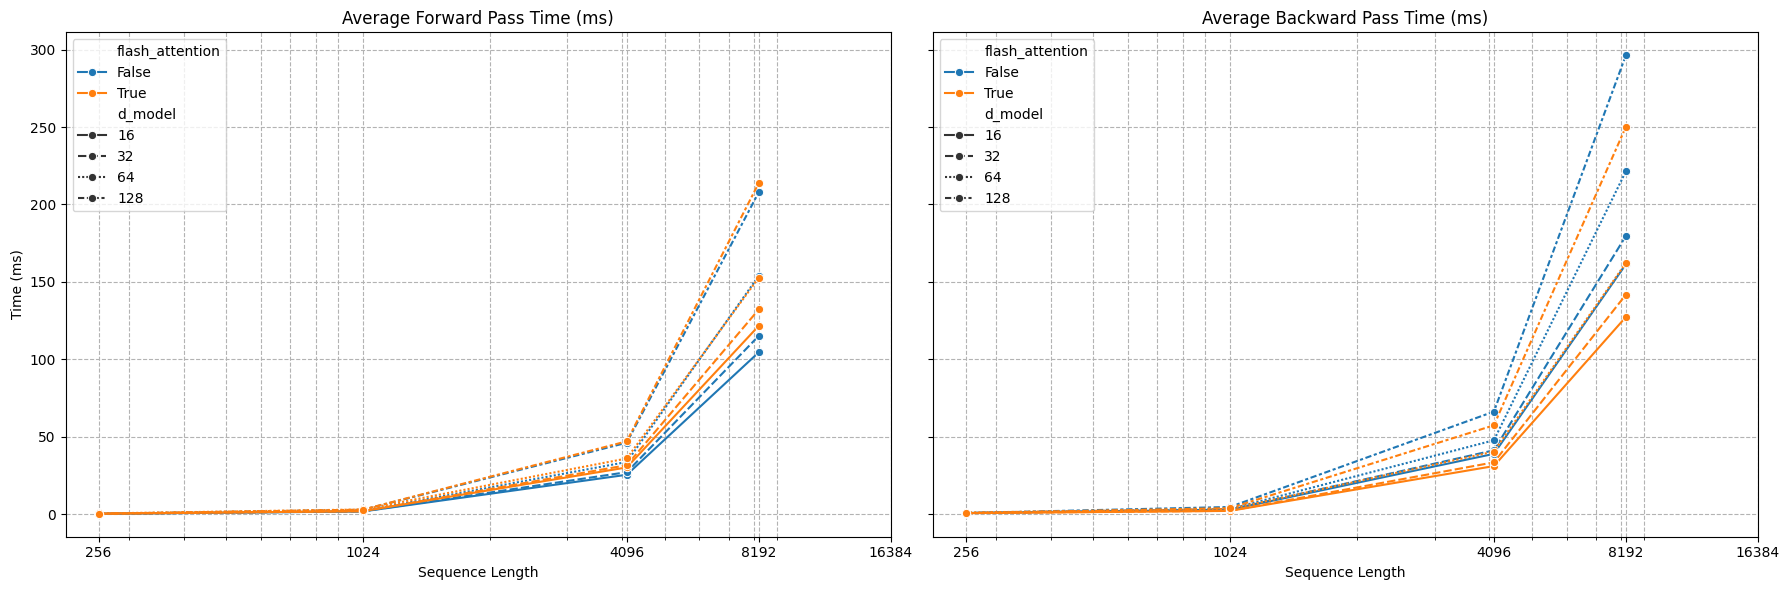

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

sns.lineplot(
    data=combined_attention_results,
    x='sequence_length',
    y='avg_fwd_time_ms',
    hue='flash_attention',
    style='d_model',
    marker='o',
    ax=axes[0]
)
axes[0].set_title('Average Forward Pass Time (ms)')
axes[0].set_xlabel('Sequence Length')
axes[0].set_ylabel('Time (ms)')
axes[0].set_xscale('log')
axes[0].set_xticks(combined_attention_results['sequence_length'].unique())
axes[0].get_xaxis().set_major_formatter(plt.ScalarFormatter())
axes[0].grid(True, which="both", ls="--", c='0.7')

sns.lineplot(
    data=combined_attention_results,
    x='sequence_length',
    y='avg_bwd_time_ms',
    hue='flash_attention',
    style='d_model',
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Average Backward Pass Time (ms)')
axes[1].set_xlabel('Sequence Length')
axes[1].set_ylabel('Time (ms)')
axes[1].set_xscale('log')
axes[1].set_xticks(combined_attention_results['sequence_length'].unique())
axes[1].get_xaxis().set_major_formatter(plt.ScalarFormatter())
axes[1].grid(True, which="both", ls="--", c='0.7')

plt.tight_layout()
plt.show()


#### Performance Comparison: Peak Memory Usage

This graph illustrates the peak memory usage during the attention operation. Lower memory usage is generally better, especially for large sequence lengths where OOM errors can occur.

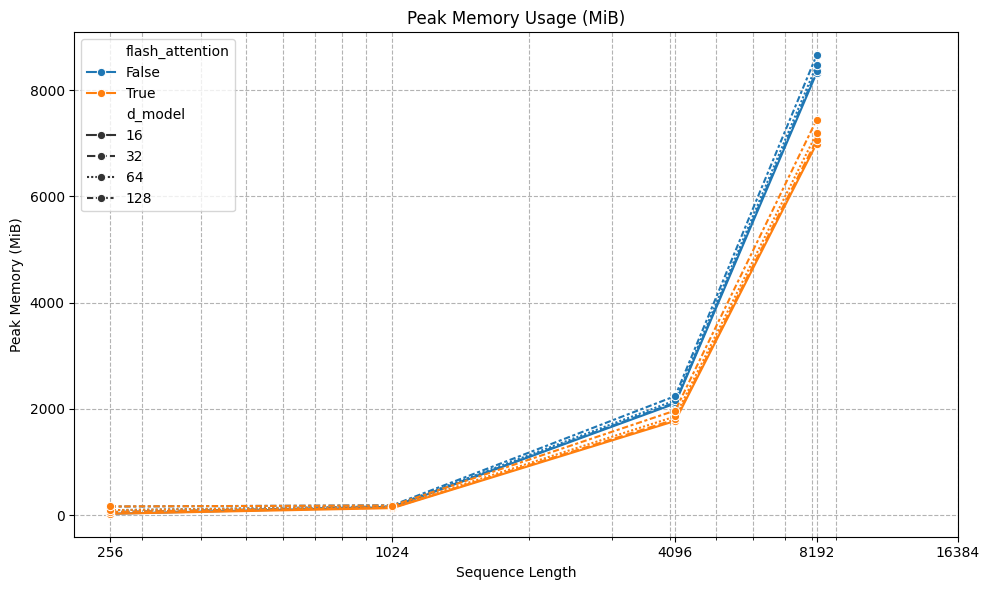

In [17]:
fig = plt.figure(figsize=(10, 6))
sns.lineplot(
    data=combined_attention_results,
    x='sequence_length',
    y='peak_memory_MiB',
    hue='flash_attention',
    style='d_model',
    marker='o'
)
plt.title('Peak Memory Usage (MiB)')
plt.xlabel('Sequence Length')
plt.ylabel('Peak Memory (MiB)')
plt.xscale('log')
plt.xticks(combined_attention_results['sequence_length'].unique())
plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()
plt.show()


### Model Benchmarking Results

Below are the average times per step for the `BasicsTransformerLM` across different benchmark modes, including comparisons with and without mixed precision. This data comes from the first `benchmark_model` run in cell `4nDJ6g5c1EJg`.

In [18]:
model_benchmark_data = {
    'Benchmark Mode': [
        'Forward Only',
        'Forward + Backward',
        'Full Train (No MP)',
        'Full Train (With MP)'
    ],
    'Average Time per Step (s)': [
        time_forward,
        time_forward_backward,
        time_full_train,
        time_mixed_precision_train
    ]
}
model_benchmark_df = pd.DataFrame(model_benchmark_data)
print("\nBasicsTransformerLM Model Benchmarking Results:")
display(model_benchmark_df)



BasicsTransformerLM Model Benchmarking Results:


,Benchmark Mode,Average Time per Step (s)
0,Forward Only,0.021599
1,Forward + Backward,0.027868
2,Full Train (No MP),0.030142
3,Full Train (With MP),0.024609


#### Model Benchmarking Performance Graph

This bar chart visualizes the average time per step for the different model benchmark modes. It highlights the impact of mixed precision on training speed.

/tmp/ipykernel_2200/4226087717.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


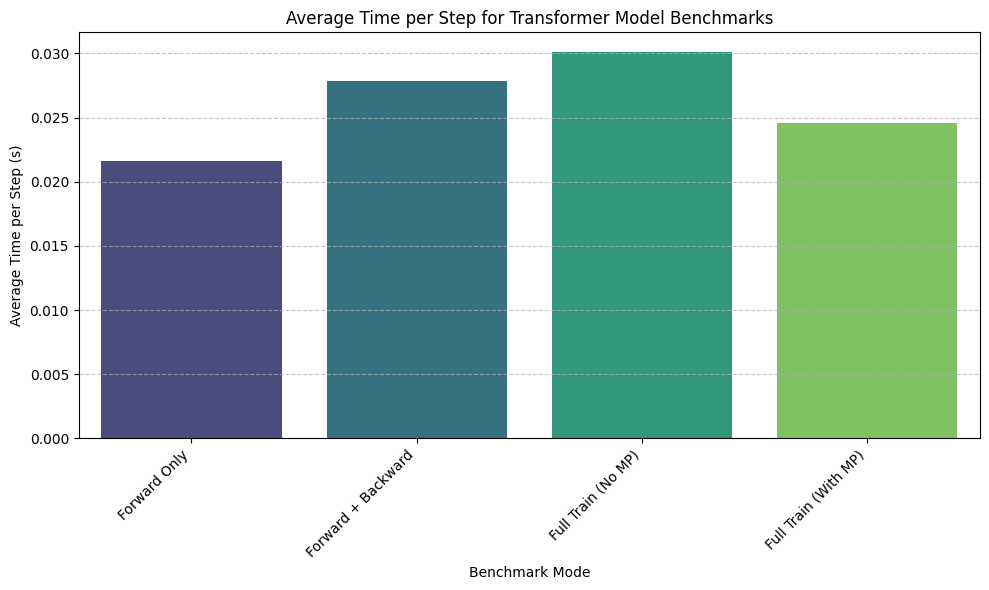

In [19]:
fig = plt.figure(figsize=(10, 6))
sns.barplot(
    data=model_benchmark_df,
    x='Benchmark Mode',
    y='Average Time per Step (s)',
    palette='viridis'
)
plt.title('Average Time per Step for Transformer Model Benchmarks')
plt.xlabel('Benchmark Mode')
plt.ylabel('Average Time per Step (s)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
